# Module 2 — Understanding the Dataset

**Social Media Bot Detection Using GNN**

| File | Contents | Rows |
|------|----------|------|
| users.csv  | User/account profiles with labels | 10,000 |
| tweets.csv | Individual post/tweet records | ~137,000 |
| edges.csv  | Social-network interaction edges | 55,000 |

**Label encoding:** 0=Human  1=Bot  2=Suspicious/Coordinated


In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT    = Path(r'c:\Social Media Bot Detection')
RAW_DIR = ROOT / 'data' / 'raw'

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid', palette='muted')
print('RAW_DIR:', RAW_DIR)

RAW_DIR: c:\Social Media Bot Detection\data\raw


## 2.1 Load Data

In [2]:
users_df  = pd.read_csv(RAW_DIR / 'users.csv',  low_memory=False)
tweets_df = pd.read_csv(RAW_DIR / 'tweets.csv', low_memory=False)
edges_df  = pd.read_csv(RAW_DIR / 'edges.csv',  low_memory=False)
with open(RAW_DIR / 'dataset_info.json') as f:
    meta = json.load(f)
print(f'Users  : {len(users_df):,} rows x {users_df.shape[1]} cols')
print(f'Tweets : {len(tweets_df):,} rows x {tweets_df.shape[1]} cols')
print(f'Edges  : {len(edges_df):,} rows x {edges_df.shape[1]} cols')

Users  : 10,000 rows x 23 cols
Tweets : 137,774 rows x 11 cols
Edges  : 55,000 rows x 5 cols


## 2.2 User Table — Column Schema

In [3]:
print('Column dtypes:')
print(users_df.dtypes.to_string())

Column dtypes:
user_id                      int64
screen_name                    str
account_type                   str
label                        int64
created_at                     str
account_age_days             int64
followers_count              int64
following_count              int64
post_count                   int64
verified                     int64
posts_per_day              float64
reply_ratio                float64
retweet_ratio              float64
mention_ratio              float64
url_ratio                  float64
hashtag_ratio              float64
duplicate_content_ratio    float64
has_profile_image            int64
has_description              int64
default_profile              int64
profile_completeness       float64
location                       str
listed_count               float64


In [4]:
users_df.head()

,user_id,screen_name,account_type,label,created_at,account_age_days,followers_count,following_count,post_count,verified,posts_per_day,reply_ratio,retweet_ratio,mention_ratio,url_ratio,hashtag_ratio,duplicate_content_ratio,has_profile_image,has_description,default_profile,profile_completeness,location,listed_count
0,106253,user_106253,bot,1,2023-03-03,304,3,4315,1479,0,5.0000,0.2397,0.8602,0.0526,0.8390,0.1972,0.8067,0,0,1,0.1698,"California, USA",2.0000
1,104685,user_104685,human,0,2020-10-11,1177,102,99,84,0,4.4608,0.0933,0.2213,0.0554,0.1738,0.3302,0.0032,1,1,1,0.5291,"Toronto, Canada",24.0000
2,101732,user_101732,human,0,2019-08-25,1590,87,4605,491,0,5.5889,0.4229,0.4414,0.2078,0.1655,0.0173,0.1337,1,1,0,0.8951,"Sydney, Australia",41.0000
3,104743,user_104743,human,0,2019-01-27,1800,36,436,166,0,2.1044,0.3324,0.0949,0.0152,0.5728,0.3728,0.0093,0,1,0,0.7602,"Seoul, South Korea",12.0000
4,104522,user_104522,human,0,2017-04-23,2444,6462,294,541,0,0.1000,0.1170,0.3336,0.0294,0.1273,0.0680,0.0373,1,1,0,0.7531,"Berlin, Germany",80.0000


In [5]:
users_df.describe()

,user_id,label,account_age_days,followers_count,following_count,post_count,verified,posts_per_day,reply_ratio,retweet_ratio,mention_ratio,url_ratio,hashtag_ratio,duplicate_content_ratio,has_profile_image,has_description,default_profile,profile_completeness,listed_count
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,9183.0000
mean,105000.5000,0.6500,1149.7851,604.8930,1309.7359,3634.0060,0.0114,21.0721,0.1992,0.4518,0.1092,0.4410,0.4063,0.3743,0.6104,0.5028,0.3929,0.5004,21.1588
std,2886.8957,0.7263,816.9697,1878.8723,3001.0737,10779.1294,0.1062,27.1185,0.1603,0.2546,0.1145,0.2631,0.2746,0.3440,0.4877,0.5000,0.4884,0.2747,57.5924
min,100001.0000,0.0000,1.0000,0.0000,4.0000,5.0000,0.0000,0.1000,0.0000,0.0005,0.0000,0.0001,0.0001,0.0000,0.0000,0.0000,0.0000,0.0009,0.0000
25%,102500.7500,0.0000,434.0000,32.0000,158.0000,361.0000,0.0000,2.3582,0.0664,0.2369,0.0222,0.2119,0.1589,0.0300,0.0000,0.0000,0.0000,0.2519,2.0000
50%,105000.5000,0.5000,1006.0000,131.0000,409.0000,996.0000,0.0000,5.0000,0.1628,0.4395,0.0720,0.4355,0.3809,0.2776,1.0000,1.0000,0.0000,0.5200,7.0000
75%,107500.2500,1.0000,1811.0000,453.2500,1126.0000,2844.2500,0.0000,34.0058,0.2982,0.6581,0.1595,0.6579,0.6376,0.7170,1.0000,1.0000,1.0000,0.7430,19.0000
max,110000.0000,2.0000,4000.0000,50000.0000,30000.0000,200000.0000,1.0000,166.4813,0.8292,0.9996,0.8124,0.9938,0.9949,0.9958,1.0000,1.0000,1.0000,0.9950,2122.0000


## 2.3 Label Distribution

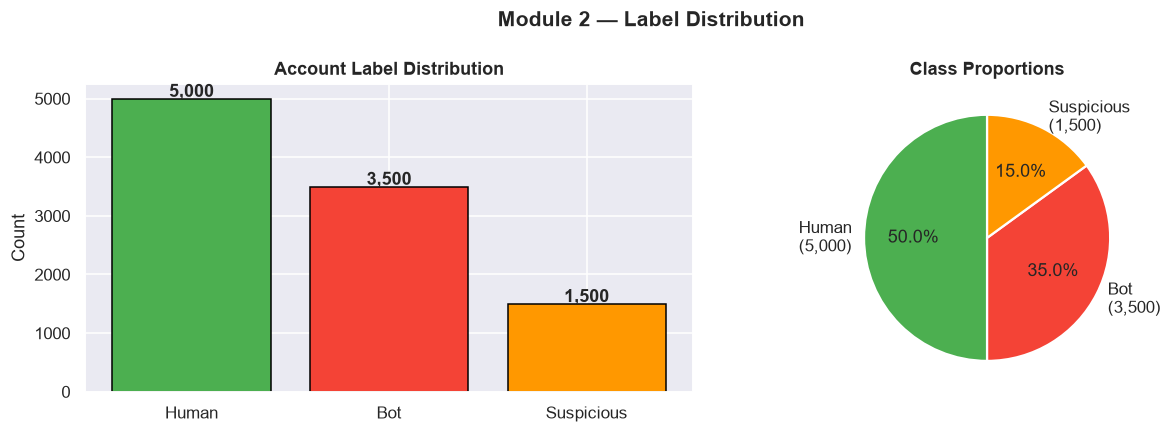

            count
label            
Human        5000
Bot          3500
Suspicious   1500


In [6]:
label_map = {0: 'Human', 1: 'Bot', 2: 'Suspicious'}
colors    = {'Human': '#4CAF50', 'Bot': '#F44336', 'Suspicious': '#FF9800'}
lc = users_df['label'].map(label_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(lc.index, lc.values, color=[colors[l] for l in lc.index], edgecolor='black')
for bar, val in zip(bars, lc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Account Label Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[1].pie(lc.values,
            labels=[f'{l}\n({v:,})' for l, v in zip(lc.index, lc.values)],
            colors=[colors[l] for l in lc.index], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportions', fontweight='bold')
plt.suptitle('Module 2 — Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RAW_DIR / 'label_distribution.png'), bbox_inches='tight', dpi=120)
plt.show()
print(lc.to_frame('count'))

## 2.4 Behavioral Feature Distributions

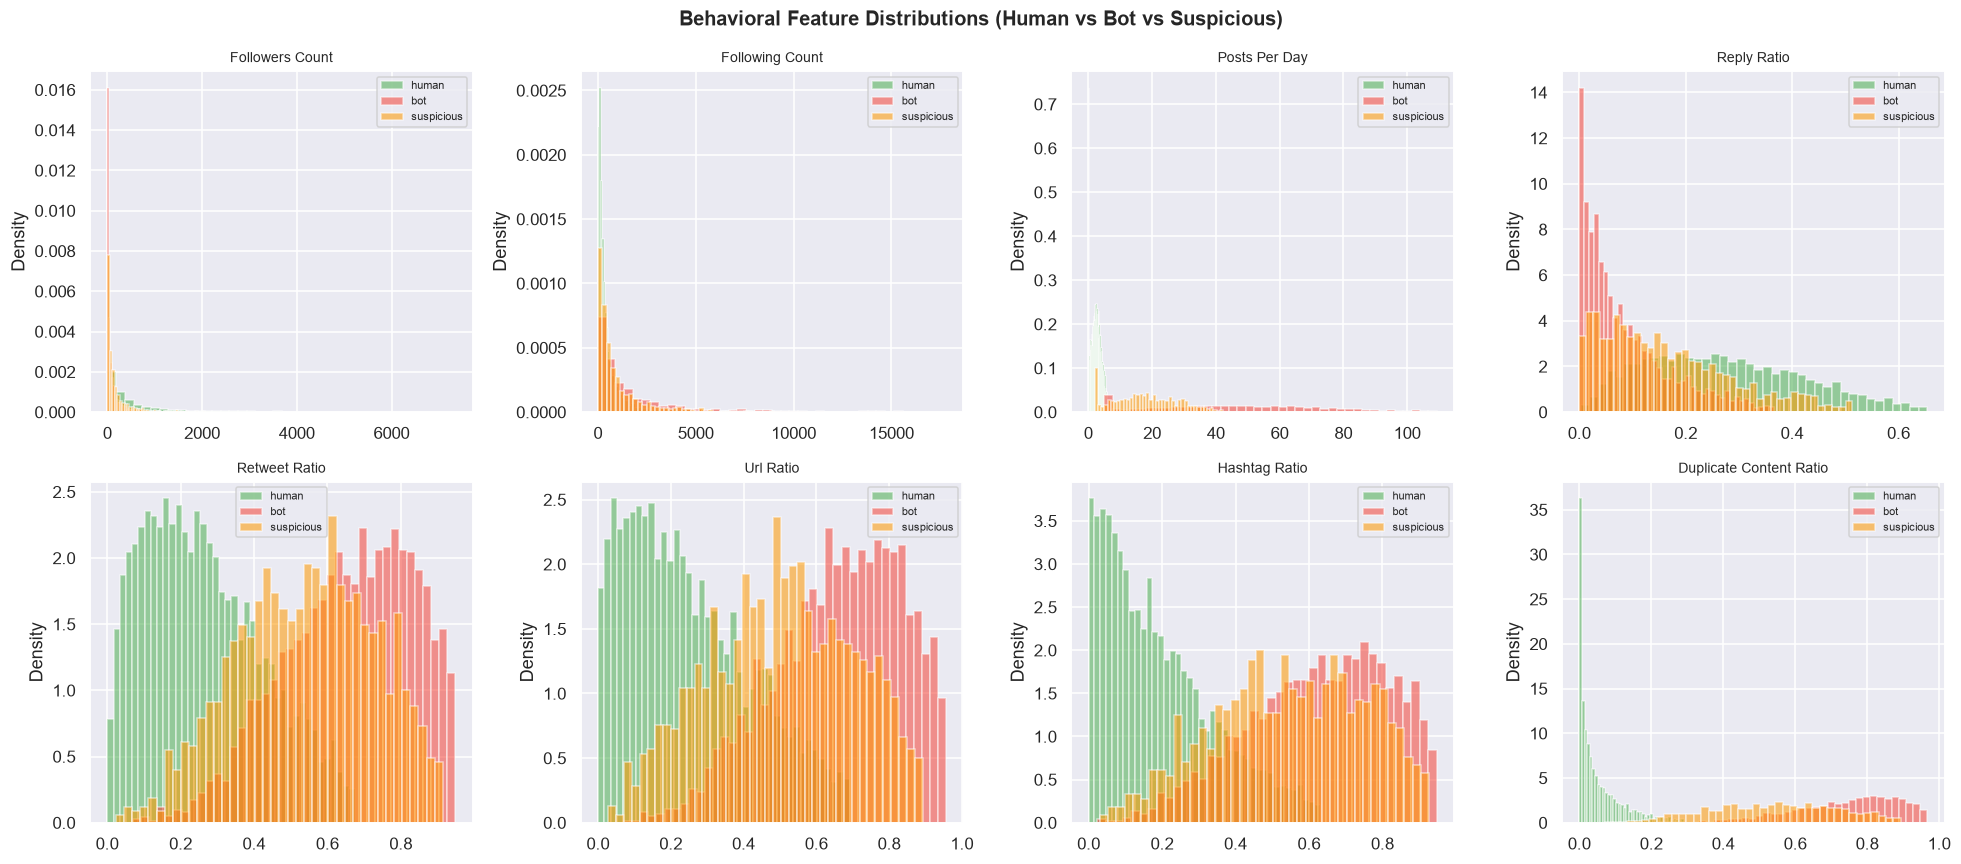

In [7]:
type_colors = {'human': '#4CAF50', 'bot': '#F44336', 'suspicious': '#FF9800'}
feature_cols = ['followers_count', 'following_count', 'posts_per_day',
                'reply_ratio', 'retweet_ratio', 'url_ratio',
                'hashtag_ratio', 'duplicate_content_ratio']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    for atype, color in type_colors.items():
        subset = users_df[users_df['account_type'] == atype][col].dropna()
        cap = subset.quantile(0.98)
        subset = subset[subset <= cap]
        axes[i].hist(subset, bins=40, alpha=0.55, color=color, label=atype, density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Density')
plt.suptitle('Behavioral Feature Distributions (Human vs Bot vs Suspicious)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RAW_DIR / 'behavioral_distributions.png'), bbox_inches='tight', dpi=120)
plt.show()

## 2.5 Followers / Following Ratio (Key Bot Signal)

In [8]:
users_df['ff_ratio'] = (users_df['followers_count'] + 1) / (users_df['following_count'] + 1)
print('Median Followers/Following ratio per account type:')
print(users_df.groupby('account_type')['ff_ratio'].median().round(3).to_string())
print()
print('Human      -> ratio ~1.3  (balanced social behavior)')
print('Bot        -> ratio ~0.04 (follows thousands, few follow back)')
print('Suspicious -> ratio ~0.16 (moderately imbalanced)')

Median Followers/Following ratio per account type:
account_type
bot          0.0360
human        1.2820
suspicious   0.1590

Human      -> ratio ~1.3  (balanced social behavior)
Bot        -> ratio ~0.04 (follows thousands, few follow back)
Suspicious -> ratio ~0.16 (moderately imbalanced)


## 2.6 Replies, Retweets & Mentions

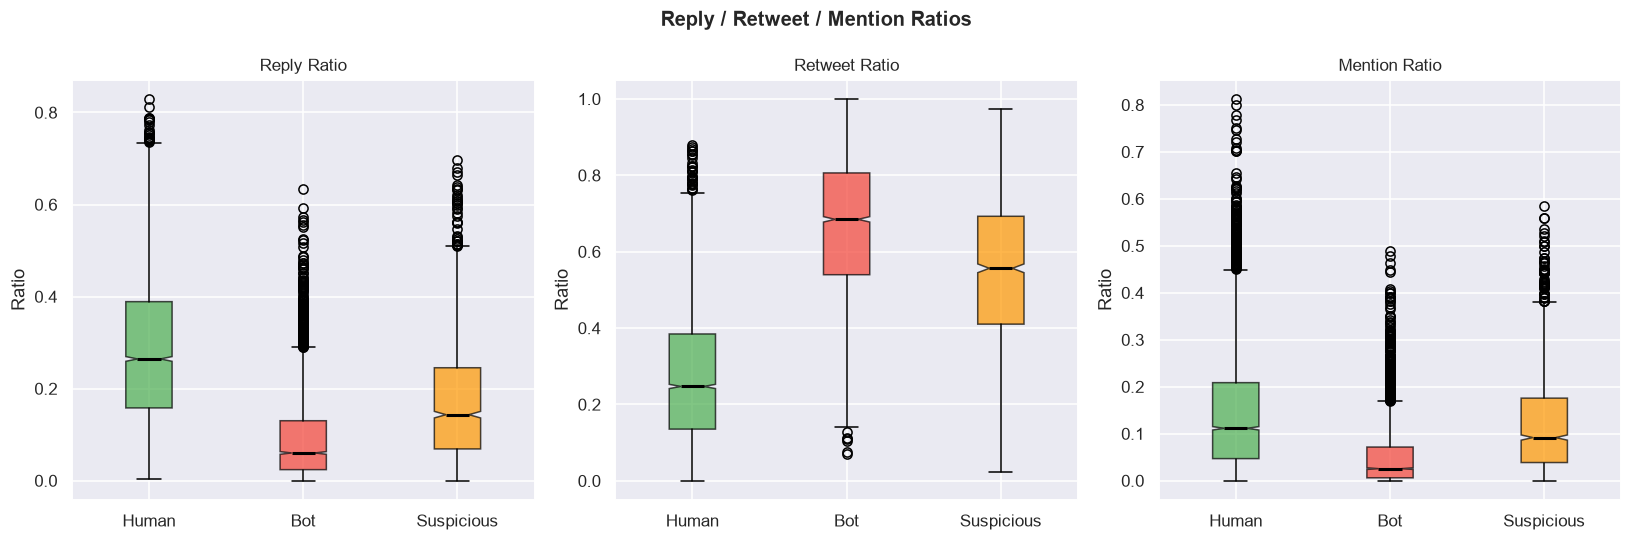

In [9]:
interaction_cols = ['reply_ratio', 'retweet_ratio', 'mention_ratio']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(interaction_cols):
    data = [users_df[users_df['account_type'] == t][col].dropna().values
            for t in ['human', 'bot', 'suspicious']]
    bp = axes[i].boxplot(data, patch_artist=True, notch=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#4CAF50', '#F44336', '#FF9800']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_xticklabels(['Human', 'Bot', 'Suspicious'])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_ylabel('Ratio')
plt.suptitle('Reply / Retweet / Mention Ratios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RAW_DIR / 'interaction_boxplots.png'), bbox_inches='tight', dpi=120)
plt.show()

## 2.7 Tweet Content Samples

In [10]:
for atype in ['human', 'bot', 'suspicious']:
    print(f'\n--- {atype.upper()} SAMPLE TWEETS ---')
    for t in tweets_df[tweets_df['account_type'] == atype]['text'].sample(3, random_state=42):
        print(f'  {t[:115]}')


--- HUMAN SAMPLE TWEETS ---
  Finally finished that project I've been working on for weeks. So relieved! #cooking
  Reading '1984' right now. Highly recommend it to anyone into climate change. #workout
  Shoutout to everyone grinding hard this week. You've got this!

--- BOT SAMPLE TWEETS ---
  BREAKING: social media is trending NOW! See the full story: https://tinyurl.com/abc123 #fff #giveaway #limitedtime
  Like and retweet for a chance to WIN $1000! Follow us first! #giveaway #limitedtime
  RT to win a FREE iPhone 15! Must follow! Limited time! https://earn.money/now

--- SUSPICIOUS SAMPLE TWEETS ---
  People are waking up to the truth about crypto. Share widely. #wakeup
  New research shows The election was stolen. Full details: http://bit.ly/xz9f2 #news #together
  Just shared this with everyone I know. You should too: https://earn.money/now #movement


## 2.8 Edge / Graph Relationships

Edge type distribution:
interaction_type
follows     22729
retweets    16991
replies      9357
mentions     5923


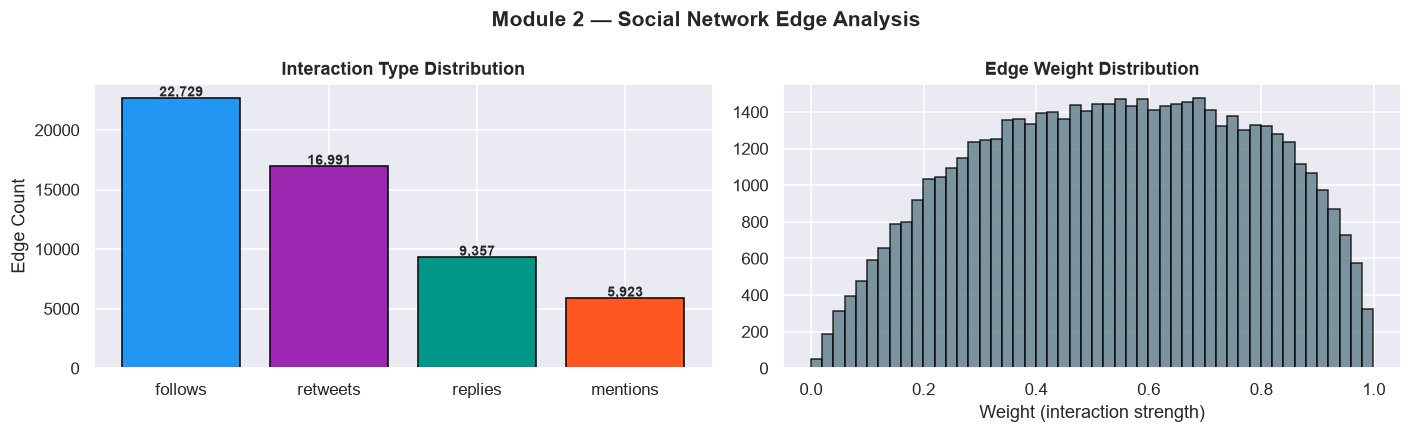

In [11]:
print('Edge type distribution:')
print(edges_df['interaction_type'].value_counts().to_string())

edge_cmap = {'follows': '#2196F3', 'retweets': '#9C27B0',
             'replies': '#009688', 'mentions': '#FF5722'}
ec = edges_df['interaction_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(ec.index, ec.values,
            color=[edge_cmap.get(t, 'grey') for t in ec.index], edgecolor='black')
for bar, val in zip(axes[0].patches, ec.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Interaction Type Distribution', fontweight='bold')
axes[0].set_ylabel('Edge Count')
axes[1].hist(edges_df['weight'], bins=50, color='#607D8B', edgecolor='black', alpha=0.8)
axes[1].set_title('Edge Weight Distribution', fontweight='bold')
axes[1].set_xlabel('Weight (interaction strength)')
plt.suptitle('Module 2 — Social Network Edge Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RAW_DIR / 'edge_analysis.png'), bbox_inches='tight', dpi=120)
plt.show()

## 2.9 Cross-Type Interaction Heatmap

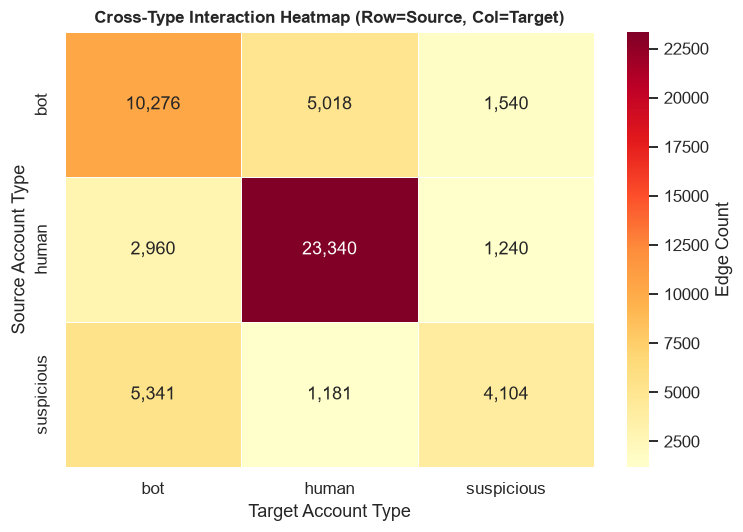

Dense Bot->Bot edges = coordinated bot cluster structure


In [12]:
uid_to_type = users_df.set_index('user_id')['account_type']
el = edges_df.copy()
el['src_type'] = el['source_user_id'].map(uid_to_type)
el['tgt_type'] = el['target_user_id'].map(uid_to_type)
el = el.dropna(subset=['src_type', 'tgt_type'])
cm = pd.crosstab(el['src_type'], el['tgt_type'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Edge Count'}, ax=ax)
ax.set_title('Cross-Type Interaction Heatmap (Row=Source, Col=Target)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Target Account Type')
ax.set_ylabel('Source Account Type')
plt.tight_layout()
plt.savefig(str(RAW_DIR / 'cross_type_heatmap.png'), bbox_inches='tight', dpi=120)
plt.show()
print('Dense Bot->Bot edges = coordinated bot cluster structure')

## 2.10 Missing Values

In [13]:
for name, df in [('users', users_df), ('tweets', tweets_df), ('edges', edges_df)]:
    m = df.isnull().sum()
    has_m = m[m > 0]
    if len(has_m) == 0:
        print(f'[{name}] => No missing values')
    else:
        print(f'[{name}] Missing:')
        for col, cnt in has_m.items():
            print(f'  {col:<30} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)')

[users] Missing:
  location                        3,042  (30.4%)
  listed_count                      817  (8.2%)
[tweets] => No missing values
[edges] => No missing values


## Module 2 Summary

| Component | Details |
|-----------|---------|
| **Users** | 10,000 accounts — 50% human, 35% bot, 15% suspicious |
| **Tweets** | ~137,000 posts with text, engagement, URL/hashtag flags |
| **Edges** | 55,000 directed interactions — follows, retweets, replies, mentions |
| **Key Bot Signals** | High posts_per_day, high url_ratio, high retweet_ratio, low ff_ratio, default_profile=1 |
| **Key Graph Signal** | Dense bot-bot clusters, suspicious-bot coordination edges |

**Next:** Module 3 — Data Cleaning & Preparation
